# 02 - Fine-Tuning IndoT5 dengan Grid Search Hyperparameter

Total eksperimen: **1 baseline + 18 grid search = 19 run**

| # | Konfigurasi | Epoch | Batch Size | Learning Rate |
|---|---|---|---|---|
| 0 | **Baseline** (default, tanpa tuning) | - | - | - |
| 1–18 | **Grid Search** | 5, 10, 15 | 4, 8 | 1e-4, 3e-5, 5e-5 |

> Setiap run dievaluasi dengan ROUGE pada `test.csv`. Model dengan ROUGE-L tertinggi disimpan sebagai model final.

In [1]:
from huggingface_hub import login
from google.colab import userdata
import os

try:
    # Ambil token "HF_TOKEN" langsung dari Secret Colab
    my_token = userdata.get('HF_TOKEN')

    if my_token:
        # Login menggunakan token
        login(token=my_token, add_to_git_credential=True)
        print("Berhasil login ke Hugging Face menggunakan Secret Colab!")
    else:
        print("Token HF_TOKEN tidak ditemukan di Secrets Colab.")

except Exception as e:
    print(f"Gagal mengambil secret: {e}")

Berhasil login ke Hugging Face menggunakan Secret Colab!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers datasets evaluate sentencepiece accelerate rouge-score -q

import shutil

# ======================================================
# folder tempat data latih csv
DRIVE_DATA_DIR = '/content/drive/MyDrive/data_latih'
# ======================================================

shutil.copy(f'{DRIVE_DATA_DIR}/train.csv', 'train.csv')
shutil.copy(f'{DRIVE_DATA_DIR}/test.csv',  'test.csv')
print("Data berhasil di-copy dari Google Drive!")


Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
Data berhasil di-copy dari Google Drive!


## 3. Import & Konfigurasi

In [3]:
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset
import pandas as pd
import evaluate
import torch
import shutil
import itertools
from pathlib import Path

MODEL_NAME = "Wikidepia/IndoT5-base"
DATA_DIR    = Path('.')
OUTPUT_ROOT = Path('/content/drive/MyDrive/models')
BEST_DIR    = OUTPUT_ROOT / 'indot5_finetuned'
LOG_DIR     = OUTPUT_ROOT / 'training_logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

PREFIX  = 'ringkas: '
MAX_IN  = 512
MAX_OUT = 150

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_NAME}')

Device : cuda
Model  : Wikidepia/IndoT5-base


## 4. Data Loading & Tokenization

In [4]:
df_train = pd.read_csv('train.csv')
df_test  = pd.read_csv('test.csv')
print(f'Train: {len(df_train)} | Test: {len(df_test)}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenisasi(examples):
    inputs = [PREFIX + str(s) for s in examples['input_whisper_segment']]
    m_in   = tokenizer(inputs, max_length=MAX_IN, truncation=True, padding='max_length')

    labels = tokenizer(
        text_target=[str(t) for t in examples['target_summary_manual']],
        max_length=MAX_OUT, truncation=True, padding='max_length'
    )

    m_in['labels'] = [
        [-100 if t == tokenizer.pad_token_id else t for t in seq]
        for seq in labels['input_ids']
    ]
    return m_in

train_ds = Dataset.from_pandas(df_train).map(tokenisasi, batched=True, remove_columns=df_train.columns.tolist())
test_ds  = Dataset.from_pandas(df_test).map(tokenisasi, batched=True, remove_columns=df_test.columns.tolist())
print('Tokenisasi selesai.')

Train: 388 | Test: 98


config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/777k [00:00<?, ?B/s]

Map:   0%|          | 0/388 [00:00<?, ? examples/s]

Map:   0%|          | 0/98 [00:00<?, ? examples/s]

Tokenisasi selesai.


## 5. Diagnostik

In [5]:
# log Cek apa yang dihasilkan model saat ini
model_test = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
tokenizer_test = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_input = PREFIX + str(df_test['input_whisper_segment'].iloc[0])[:300]
inputs = tokenizer_test(sample_input, return_tensors='pt', max_length=512, truncation=True).to(DEVICE)
outputs = model_test.generate(**inputs, max_new_tokens=100)

print("PREFIX yang dipakai:", repr(PREFIX))
print("Input awal (Whisper):", sample_input[:100], "...")
print("Output model mentah:", tokenizer_test.decode(outputs[0], skip_special_tokens=True))
print("Referensi (Ringkasan Manual):", str(df_test['target_summary_manual'].iloc[0])[:200], "...")

# Cleanup setelah diagnostik
del model_test, tokenizer_test
import torch, gc
torch.cuda.empty_cache()
gc.collect()
print("VRAM diagnostik sudah dibersihkan.")

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

PREFIX yang dipakai: 'ringkas: '
Input awal (Whisper): ringkas: Hei laporan Aruskas Cumlah Aruskas bersih dari aktivitas operasi sebesar minus 154.1 triliu ...
Output model mentah: operasi sebesar minus 154. 1 triliun rupiah. operasi sebesar minus 154. 1 triliun rupiah. kaskas investasi sebesar minus 154. 1 triliun rupiah.kaskaskas investasi sebesar minus investasi sebesar minuskaskas bersih dari aktivitas operasi sebesarkas
Referensi (Ringkasan Manual): Laporan Keuangan Pemerintah Pusat Tahun Anggaran 2024 memuat Laporan Arus Kas dengan defisit bersih operasi sebesar Rp154,1 triliun dan investasi sebesar Rp414,4 triliun, didukung surplus pendanaan se ...
VRAM diagnostik sudah dibersihkan.


## 6. Fungsi Inti Trainer & ROUGE

In [6]:
LOCAL_BEST_DIR = Path('/content/model_juara_lokal')
rouge = evaluate.load('rouge')

def hitung_rouge(model, test_dataset):
    """Hitung ROUGE dengan model yang sudah ditraining"""
    from torch.utils.data import DataLoader

    model.eval()
    preds = []
    # Ambil referensi dari kolom target ringkasan
    refs  = df_test['target_summary_manual'].tolist()

    test_dataset.set_format('torch')
    loader = DataLoader(test_dataset, batch_size=2)

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            outputs = model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=MAX_OUT,
                no_repeat_ngram_size=3,
                repetition_penalty=2.0, # Mencegah kata berulang
                num_beams=4,
                early_stopping=True,
            )
            decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            preds.extend(decoded)

    preds = [p.replace(PREFIX, '').strip() for p in preds]

    if preds:
        print(f"  [Cek Prediksi] T5     : {preds[0][:100]}...")
        print(f"  [Cek Referensi] Manual: {refs[0][:100]}...")

    pairs = [(p, r) for p, r in zip(preds, refs) if p.strip()]

    if not pairs:
        return {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

    p_clean, r_clean = zip(*pairs)
    scores = rouge.compute(predictions=list(p_clean), references=list(r_clean), use_stemmer=False)
    return {k: round(v, 4) for k, v in scores.items()}

def buat_trainer(model, params, run_dir):
    target_bs = params['per_device_train_batch_size']

    args = Seq2SeqTrainingArguments(
        output_dir=str(run_dir),
        num_train_epochs=params['num_train_epochs'],
        per_device_train_batch_size=target_bs,
        gradient_accumulation_steps=1,
        per_device_eval_batch_size=4,
        learning_rate=params['learning_rate'],
        warmup_steps=50,
        weight_decay=0.01,
        max_grad_norm=1.0,
        logging_steps=10,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        save_total_limit=1,
        predict_with_generate=True,
        generation_max_length=MAX_OUT,
        fp16=False,
        bf16=True,
        report_to='none',
    )

    return Seq2SeqTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=test_ds,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model, padding=True),
        processing_class=tokenizer,
    )

def jalankan_satu_run(run_label, params, run_dir, hasil_list, best_state):
    print(f'\n{"="*55}')
    print(f'[{run_label}] Epoch={params["num_train_epochs"]}  BS={params["per_device_train_batch_size"]}  LR={params["learning_rate"]}')
    print(f'{"="*55}')

    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
    trainer = buat_trainer(model, params, run_dir)

    trainer.train()
    model = trainer.model

    scores = hitung_rouge(model, test_ds)
    print(f'  ROUGE-1={scores["rouge1"]}  ROUGE-2={scores["rouge2"]}  ROUGE-L={scores["rougeL"]}')

    hasil_list.append({
        'run'          : run_label,
        'epoch'        : params['num_train_epochs'],
        'batch_size'   : params['per_device_train_batch_size'],
        'learning_rate': params['learning_rate'],
        'rouge1'       : scores['rouge1'],
        'rouge2'       : scores['rouge2'],
        'rougeL'       : scores['rougeL'],
    })

    if scores['rougeL'] > best_state['rouge_l']:
        best_state['rouge_l'] = scores['rougeL']
        best_state['config']  = params.copy()

        trainer.save_model(str(LOCAL_BEST_DIR))
        tokenizer.save_pretrained(str(LOCAL_BEST_DIR))
        print(f'⭐ Model terbaik baru berhasil tersimpan!')

    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if run_dir.exists():
        shutil.rmtree(run_dir)
        print(f'Folder {run_dir.name} dihapus.')

## 6. Eksekusi 19 Hyperparameter

In [7]:
import itertools
import pandas as pd
from transformers import AutoModelForSeq2SeqLM
import torch
import shutil
from pathlib import Path

hasil_eksperimen = []
best_state = {'rouge_l': -1, 'config': None, 'dir': None}

# =====================================================================
# TAHAP 1: SETUP PENYIMPANAN LOKAL COLAB
# =====================================================================
LOCAL_ROOT = Path('/content/models_temp')
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_BEST_DIR = Path('/content/model_juara_lokal')

# =====================================================================
# TAHAP 2: PENGUJIAN BASELINE (ZERO-SHOT)
# =====================================================================
print("MENGUJI EXP-BASE: ZERO-SHOT (MODEL MENTAHAN TANPA TRAINING)")

# Load model mentah dari HuggingFace
model_mentah = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

# Langsung meringkas data test (Zero-Shot)
skor_baseline = hitung_rouge(model_mentah, test_ds)
print(f"  [EXP-BASE] ROUGE-1: {skor_baseline['rouge1']} | ROUGE-2: {skor_baseline['rouge2']} | ROUGE-L: {skor_baseline['rougeL']}")

hasil_eksperimen.append({
    'run'          : 'EXP-BASE (Zero-Shot)',
    'epoch'        : 0,
    'batch_size'   : '-',
    'learning_rate': '-',
    'rouge1'       : skor_baseline['rouge1'],
    'rouge2'       : skor_baseline['rouge2'],
    'rougeL'       : skor_baseline['rougeL'],
})

# Bersihkan VRAM GPU
del model_mentah
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =====================================================================
# TAHAP 3: PENGUJIAN HYPERPARAMETER (FINE-TUNING)
# =====================================================================
epochs = [5, 10, 15]
batch_sizes = [4, 8]
learning_rates = [1e-4, 5e-5, 3e-5]

kombinasi = list(itertools.product(epochs, batch_sizes, learning_rates))
print(f"\nMEMULAI {len(kombinasi)} EKSPERIMEN FINE-TUNING...")

for i, (ep, bs, lr) in enumerate(kombinasi, 1):
    run_label = f"EXP-{i:03d}"
    params = {
        'num_train_epochs': ep,
        'per_device_train_batch_size': bs,
        'learning_rate': lr
    }

    run_dir = LOCAL_ROOT / f"run_{run_label}_ep{ep}_bs{bs}_lr{lr}"
    jalankan_satu_run(run_label, params, run_dir, hasil_eksperimen, best_state)

# =====================================================================
# TAHAP 4: TAMPILKAN HASIL AKHIR
# =====================================================================
df_hasil = pd.DataFrame(hasil_eksperimen)
print("\nREKAPITULASI HASIL EKSPERIMEN")
display(df_hasil)

df_hasil.to_csv(OUTPUT_ROOT / 'rekap_eksperimen_skripsi.csv', index=False)
print("File CSV rekapitulasi berhasil disimpan di Drive!")

print("Mengirim Model Terbaik ke Google Drive...")
if LOCAL_BEST_DIR.exists():
    if BEST_DIR.exists():
        shutil.rmtree(BEST_DIR)
    shutil.copytree(str(LOCAL_BEST_DIR), str(BEST_DIR))
    print(f"Succses! Model terbaik sudah ter-upload ke: {BEST_DIR}")

MENGUJI EXP-BASE: ZERO-SHOT (MODEL MENTAHAN TANPA TRAINING)


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  [Cek Prediksi] T5     : aruskas. Hei laporan Arus Kas hei Laporan Operasional Equitas dan Bubahan ekuitia entitas yang ada p...
  [Cek Referensi] Manual: Laporan Keuangan Pemerintah Pusat Tahun Anggaran 2024 memuat Laporan Arus Kas dengan defisit bersih ...
  [EXP-BASE] ROUGE-1: 0.2277 | ROUGE-2: 0.0611 | ROUGE-L: 0.1271

MEMULAI 18 EKSPERIMEN FINE-TUNING...

[EXP-001] Epoch=5  BS=4  LR=0.0001


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Cek Prediksi] T5     : dan kebijakan fiskal, juga menyampaikan laporan kinerja pemerintah. Pemerintah akan meningkatkan kua...
  [Cek Referensi] Manual: Laporan Keuangan Pemerintah Pusat Tahun Anggaran 2024 memuat Laporan Arus Kas dengan defisit bersih ...
  ROUGE-1=0.2618  ROUGE-2=0.0579  ROUGE-L=0.1189
Folder run_EXP-018_ep15_bs8_lr3e-05 dihapus.

REKAPITULASI HASIL EKSPERIMEN


,run,epoch,batch_size,learning_rate,rouge1,rouge2,rougeL
0,EXP-BASE (Zero-Shot),0,-,-,0.2277,0.0611,0.1271
1,EXP-001,5,4,0.0001,0.2827,0.0607,0.1281
2,EXP-002,5,4,0.00005,0.2641,0.0604,0.1248
3,EXP-003,5,4,0.00003,0.2472,0.0510,0.1140
4,EXP-004,5,8,0.0001,0.2749,0.0632,0.1273
5,EXP-005,5,8,0.00005,0.2605,0.0551,0.1213
6,EXP-006,5,8,0.00003,0.2767,0.0618,0.1295
7,EXP-007,10,4,0.0001,0.3364,0.0984,0.1830
8,EXP-008,10,4,0.00005,0.2841,0.0672,0.1346
9,EXP-009,10,4,0.00003,0.2686,0.0605,0.1222


File CSV rekapitulasi berhasil disimpan di Drive!
Mengirim Model Terbaik ke Google Drive...
Succses! Model terbaik sudah ter-upload ke: /content/drive/MyDrive/models/indot5_finetuned


## 8. Visualisasi Hasil

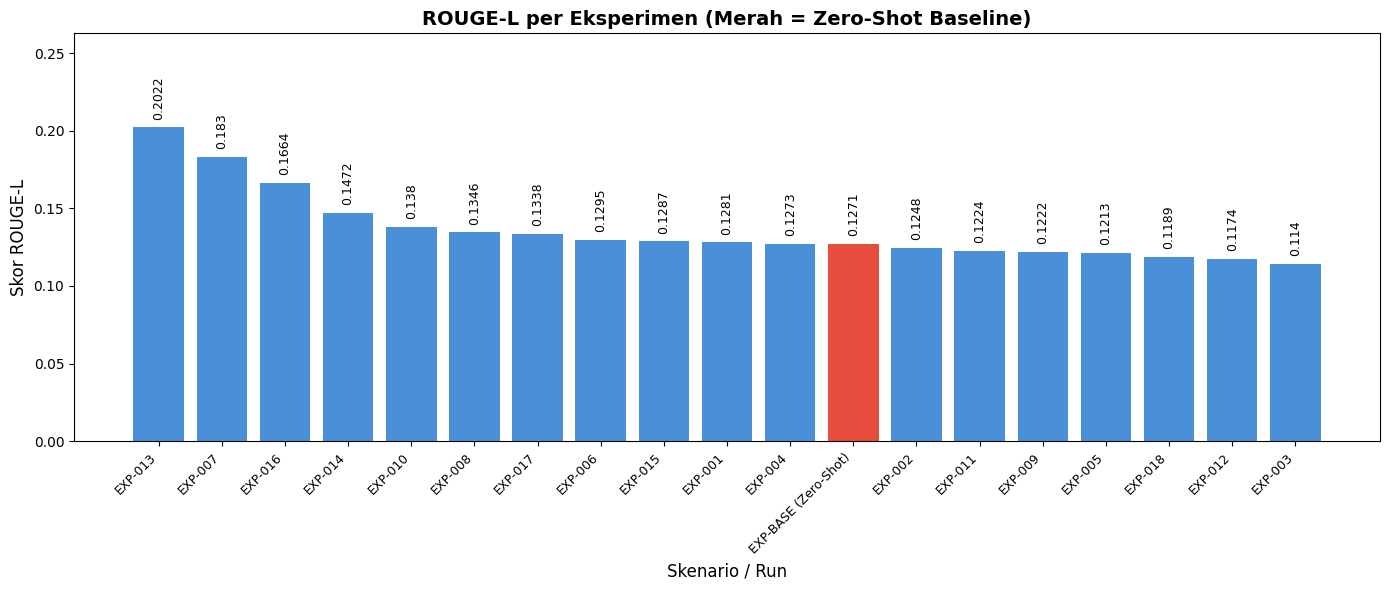

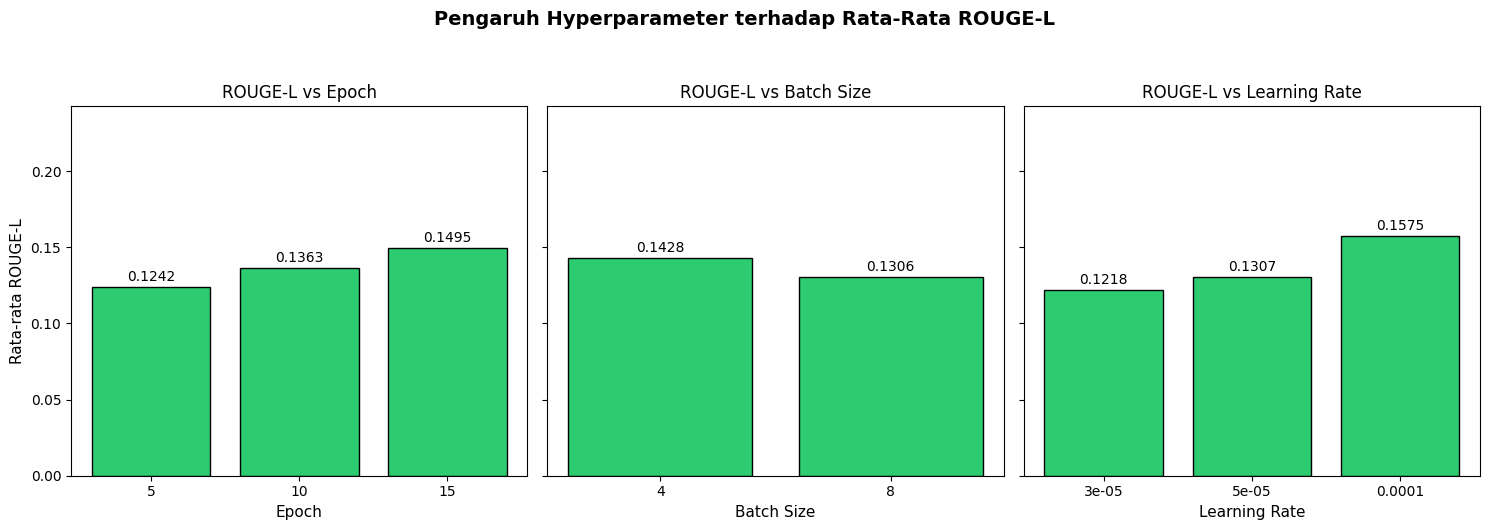

Grafik visualisasi sudah Siap!


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Urutkan berdasarkan ROUGE-L tertinggi
df_hasil_sorted = df_hasil.sort_values('rougeL', ascending=False).reset_index(drop=True)

# ==============================================================
# GRAFIK 1: KESELURUHAN ROUGE-L PER RUN
# ==============================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Warnai merah khusus untuk Zero-Shot model tanpa tuning
colors = ['#E74C3C' if 'Zero-Shot' in str(r) else '#4A90D9' for r in df_hasil_sorted['run']]
bars = ax.bar(df_hasil_sorted['run'], df_hasil_sorted['rougeL'], color=colors)

ax.set_title('ROUGE-L per Eksperimen (Merah = Zero-Shot Baseline)', fontsize=14, fontweight='bold')
ax.set_xlabel('Skenario / Run', fontsize=12)
ax.set_ylabel('Skor ROUGE-L', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4),
            ha='center', va='bottom', fontsize=9, rotation=90)

ax.set_ylim(0, max(df_hasil_sorted['rougeL']) * 1.3)

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'rouge_per_run.png', dpi=150, bbox_inches='tight')
plt.show()


# ==============================================================
# GRAFIK 2: PENGARUH HYPERPARAMETER
# ==============================================================
df_grid = df_hasil[df_hasil['run'] != 'EXP-BASE (Zero-Shot)']

fig2, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig2.suptitle('Pengaruh Hyperparameter terhadap Rata-Rata ROUGE-L', fontsize=14, fontweight='bold', y=1.05)

for ax, col, label in zip(axes, ['epoch', 'batch_size', 'learning_rate'], ['Epoch', 'Batch Size', 'Learning Rate']):
    g = df_grid.groupby(col)['rougeL'].mean().reset_index()
    bars_hp = ax.bar(g[col].astype(str), g['rougeL'], color='#2ECC71', edgecolor='black') # Tambah edgecolor biar tegas

    ax.set_title(f'ROUGE-L vs {label}', fontsize=12)
    ax.set_xlabel(label, fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Rata-rata ROUGE-L', fontsize=11)

    for bar in bars_hp:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 4),
                ha='center', va='bottom', fontsize=10)

axes[0].set_ylim(0, max(df_grid['rougeL']) * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'visualisasi_hyperparameter.png', dpi=150, bbox_inches='tight')
plt.show()

print('Grafik visualisasi sudah Siap!')

In [9]:
import evaluate
from torch.utils.data import DataLoader
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

print("EVALUASI FINAL: MODEL TERBAIK SETELAH TUNING")

print(f"Memuat Model Terbaik dari: {BEST_DIR}...")
model_juara = AutoModelForSeq2SeqLM.from_pretrained(BEST_DIR).to(DEVICE)
tokenizer_juara = AutoTokenizer.from_pretrained(BEST_DIR)

model_juara.eval()
preds_final = []
# Ambil referensi dari kolom target yang baru
refs_final = df_test['target_summary_manual'].tolist()

test_ds.set_format('torch')
loader_final = DataLoader(test_ds, batch_size=2)

print("Sedang memproses evaluasi akhir...")
with torch.no_grad():
    for batch in loader_final:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        outputs = model_juara.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_OUT,
            no_repeat_ngram_size=3,
            num_beams=4,
            repetition_penalty=2.0,
            early_stopping=True,
        )
        decoded = tokenizer_juara.batch_decode(outputs, skip_special_tokens=True)
        preds_final.extend(decoded)

preds_final = [p.replace(PREFIX, '').strip() for p in preds_final]

rouge_final = evaluate.load('rouge')
pairs = [(p, r) for p, r in zip(preds_final, refs_final) if p.strip()]

if pairs:
    p_clean, r_clean = zip(*pairs)
    scores_final = rouge_final.compute(predictions=list(p_clean), references=list(r_clean), use_stemmer=False)

    print("\n=======================================================")
    print("SKOR ROUGE FINAL MODEL TERBAIK")
    print("=======================================================")
    print(f"  ROUGE-1 : {round(scores_final['rouge1'], 4)}")
    print(f"  ROUGE-2 : {round(scores_final['rouge2'], 4)}")
    print(f"  ROUGE-L : {round(scores_final['rougeL'], 4)}")

    print("\nBANDINGKAN HASIL TEKS:")
    # Sudah di-update istilahnya biar nggak bingung lagi!
    print(f"  [Ringkasan Manual Asli] : {r_clean[0][:200]}...")
    print(f"  [Prediksi Model IndoT5] : {p_clean[0][:200]}...")
else:
    print("Gagal menghitung ROUGE.")

del model_juara
if torch.cuda.is_available():
    torch.cuda.empty_cache()

EVALUASI FINAL: MODEL TERBAIK SETELAH TUNING
Memuat Model Terbaik dari: /content/drive/MyDrive/models/indot5_finetuned...


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Sedang memproses evaluasi akhir...

SKOR ROUGE FINAL MODEL TERBAIK
  ROUGE-1 : 0.3599
  ROUGE-2 : 0.1178
  ROUGE-L : 0.2007

BANDINGKAN HASIL TEKS:
  [Ringkasan Manual Asli] : Laporan Keuangan Pemerintah Pusat Tahun Anggaran 2024 memuat Laporan Arus Kas dengan defisit bersih operasi sebesar Rp154,1 triliun dan investasi sebesar Rp414,4 triliun, didukung surplus pendanaan se...
  [Prediksi Model IndoT5] : LKPP 2024 menyampaikan Laporan Keuangan Pemerintah Pusat, dan Hasil Pemeriksaan LAPBN 2025. Selain itu, laporan keuangan yang diapresiasi untuk peningkatan kualitas anggaran pendidikan, serta pertumbu...
